# CS4320 - Applied Machine Learning

## Homework 2: Decision trees and machine learning fundamentals 

**Please type your name and A number here:**

In [22]:
Name = "Hans Gamlien"
assert Name != "", 'Please enter your name in the above quotation marks, thanks!'

A_number = "A02451972"
assert A_number != "", 'Please enter your A-number in the above quotation marks, thanks!'

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.size"] = 16

from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier

## Introducing the data set
 
For this  assignment you'll be looking at Kaggle's [Spotify Song Attributes](https://www.kaggle.com/geomack/spotifyclassification/) dataset.
The dataset contains a number of features of songs from 2017 and a binary variable `target` that represents whether the user liked the song (encoded as 1) or not (encoded as 0). See the documentation of all the features [here](https://developer.spotify.com/documentation/web-api/reference/get-audio-features). 

This dataset is publicly available on Kaggle, and you will have to download it yourself. Follow the steps below to get the data CSV. 

1. If you do not have an account with [Kaggle](https://www.kaggle.com/), you will first need to create one (it's free).
2. Login to your account and [download](https://www.kaggle.com/geomack/spotifyclassification/download) the dataset.
3. Unzip the data file if needed, then rename it to `spotify.csv`, and move it to the same directory as this notebook.

## Exercise 1: Exploratory data analysis

rubric={points:30}

#### 1(a) 
rubric={points:2}

Read in the data CSV and store it as a pandas dataframe named `spotify_df`. The first column of the .csv file should be set as the index.

In [24]:
spotify_df = pd.read_csv('spotify.csv', index_col=0)



#### 1(b)
rubric={points:2}

Run the following line of code to split the data. How many training and test examples do we have?

> Note: we are setting the `random_state` so that everyone has the same split on their assignments. This will make it easier for the TAs to grade.

In [25]:
# Do not modify this cell
df_train, df_test = train_test_split(spotify_df, test_size=0.25, random_state=123)

In [26]:
print(f"Training examples: {len(df_train)}")
print(f"Test examples: {len(df_test)}")
#Hello TA



Training examples: 1512
Test examples: 505


#### 1(c)
rubric={points:4}

- Print out the output of `describe()` **on the training split**. This will compute some summary statistics of the numeric columns.
- Which feature has the smallest range? 

> Hint: You can subtract the min value from the max value of the column to get the range.

Note that `describe` returns another DataFrame.

In [27]:
print(df_train.describe())

       acousticness  danceability    duration_ms       energy  \
count   1512.000000   1512.000000    1512.000000  1512.000000   
mean       0.185337      0.617565  247606.240741     0.682022   
std        0.257866      0.163086   81841.143743     0.211498   
min        0.000005      0.122000   16042.000000     0.014800   
25%        0.009460      0.512000  200072.000000     0.564000   
50%        0.063700      0.629500  230100.000000     0.713500   
75%        0.253000      0.738250  274041.750000     0.847250   
max        0.995000      0.984000  849960.000000     0.997000   

       instrumentalness          key     liveness     loudness         mode  \
count       1512.000000  1512.000000  1512.000000  1512.000000  1512.000000   
mean           0.139041     5.406746     0.189816    -7.089587     0.619048   
std            0.279536     3.635880     0.154115     3.841885     0.485782   
min            0.000000     0.000000     0.018800   -33.097000     0.000000   
25%            0.00

In [28]:
desc = df_train.describe()
ranges = desc.loc['max'] - desc.loc['min']
print("Ranges for each feature:")
print(ranges)
print(f"\nFeature with smallest range: {ranges.idxmin()} (range: {ranges.min():.6f})")


Ranges for each feature:
acousticness             0.994995
danceability             0.862000
duration_ms         833918.000000
energy                   0.982200
instrumentalness         0.976000
key                     11.000000
liveness                 0.950200
loudness                32.790000
mode                     1.000000
speechiness              0.792900
tempo                  171.472000
time_signature           4.000000
valence                  0.956100
target                   1.000000
dtype: float64

Feature with smallest range: speechiness (range: 0.792900)


#### 1(d) 
rubric={points:12}

Let's focus on the following features:

- danceability
- tempo
- energy
- valence

For each of these features (in order), produce a histogram that shows the distribution of the feature values in the training set, **separated for positive and negative examples**. 
By "positive examples" we mean target = 1 (user liked the song, positive sentiment) and by "negative examples" we mean target = 0 (used disliked the song, negative sentiment). As an example, here is what the histogram would look like for a different feature, loudness  

<img src="https://drive.google.com/thumbnail?id=1vgj2Hz-d5puIyf-nxlO_hjLxDJ9Q8I9y&sz=w600" alt="drawing"/>:


(You don't have to match all the details exactly, such as colour, but your histograms should look something like this, with a reasonable number of bins to see the shape of the distribution.) As shown above, there are two different histograms, one for target = 0 and one for target = 1, and they are overlaid on top of each other. The histogram above shows that extremely quiet songs tend to be disliked (more blue bars than orange on the left) and very loud songs also tend to be disliked (more blue than orange on the far right).

To adhere to the [DRY (Don't Repeat Yourself)](https://en.wikipedia.org/wiki/Don%27t_repeat_yourself) principle, make sure you use a `for` loop for your plotting, rather than repeating the plotting code 4 times. For this to work, I used `plt.show()` at the end of your loop, which draws the figure and resets the canvas for your next plot.

Here is some code that separates out the dataset into positive and negative examples, to help you get started:

In [29]:
# Do not modify the code  
negative_examples = df_train.query("target == 0")
positive_examples = df_train.query("target == 1")

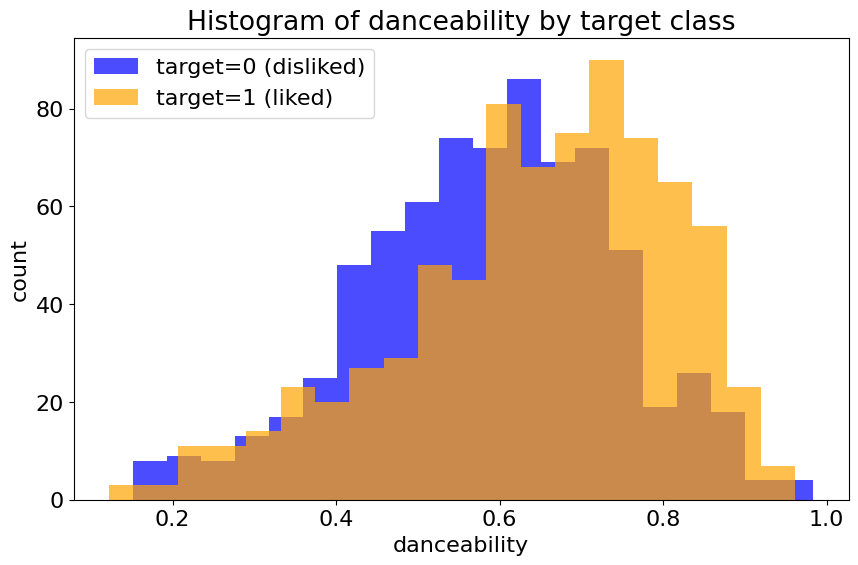

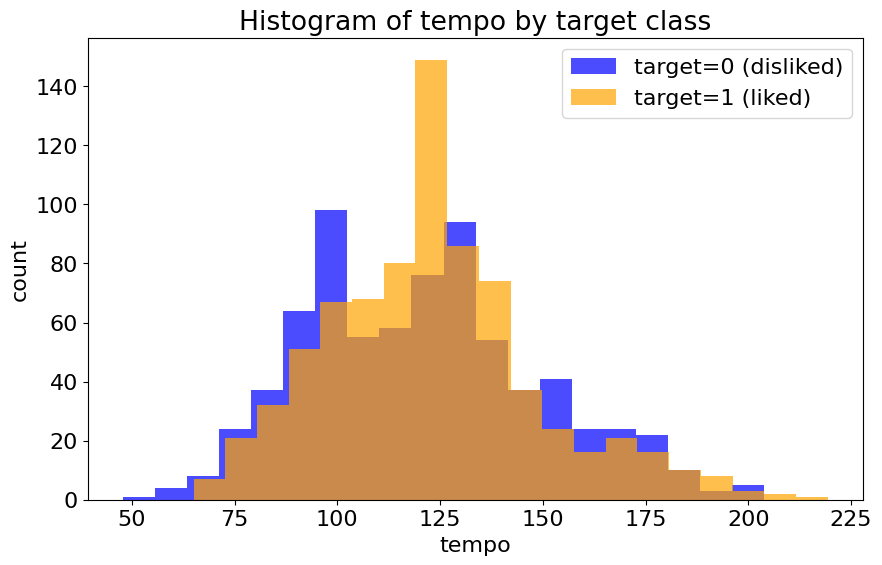

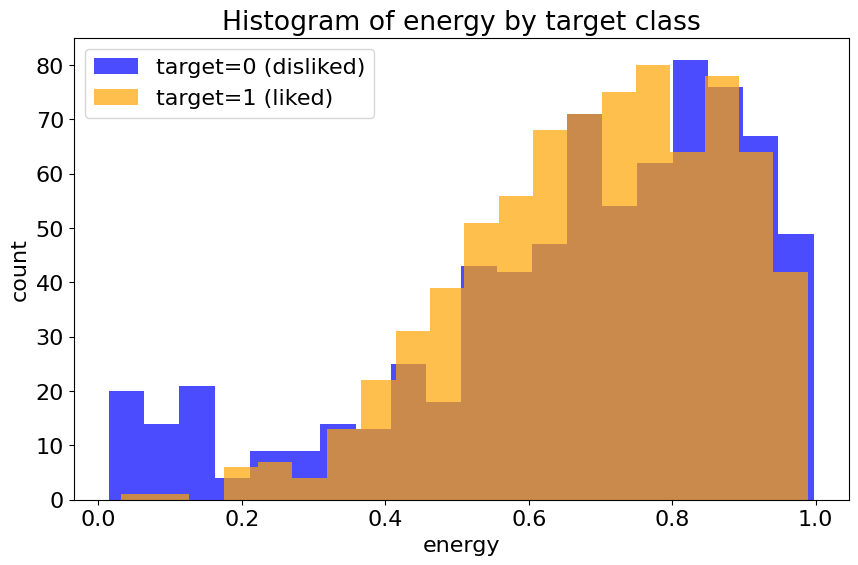

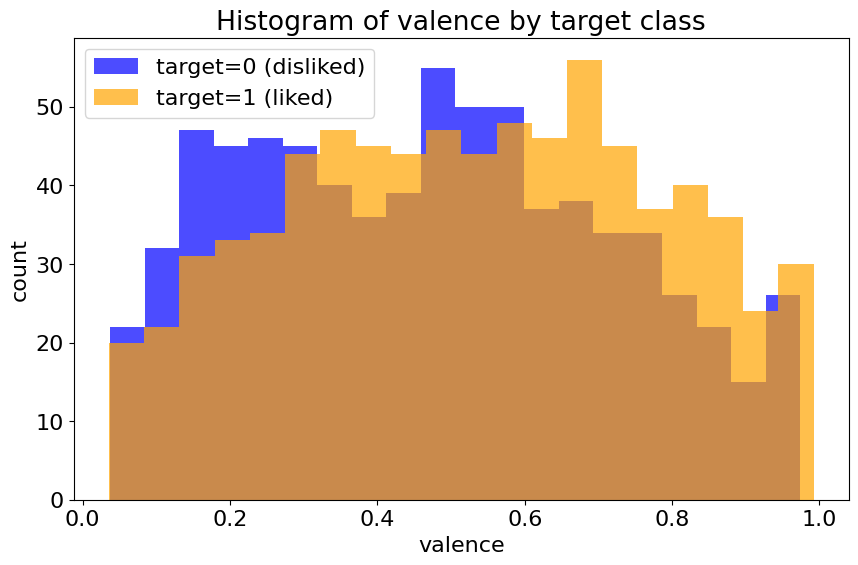

In [30]:
features = ['danceability', 'tempo', 'energy', 'valence']

for feature in features:
    plt.figure(figsize=(10, 6))
    plt.hist(negative_examples[feature], bins=20, alpha=0.7, label='target=0 (disliked)', color='blue')
    plt.hist(positive_examples[feature], bins=20, alpha=0.7, label='target=1 (liked)', color='orange')
    plt.xlabel(feature)
    plt.ylabel('count')
    plt.title(f'Histogram of {feature} by target class')
    plt.legend()
    plt.show()


#### 1(e)
rubric={points:4}

Let's say you had to make a decision stump (decision tree with depth 1), _by hand_, to predict the target class. Just from looking at the plots above, describe a reasonable split (feature name and threshold) and what class you would predict in the two cases. For example, in the loudness histogram provided earlier on, it seems that very large values of loudness are generally disliked (more blue on the right side of the histogram), so you might answer something like this: "A reasonable split would be to predict 0 if loudness > -5 (and predict 1 otherwise)."

Type your answer here:

I would probably make a split to predict 0 if valence <0.4; predict 1 otherwise. 

#### 1(f)
rubric={points:2}

Let's say that, for a particular feature, the histograms of that feature are identical for the two target classes. Does that mean the feature is not useful for predicting the target class?



Type your answer here:

No, identical histograms don't necessarily mean the feature is useless. The feature could still be useful when combined with other features in a decision tree


#### 1(g) 
rubric={points:4}

Note that the dataset includes two free text features labeled `song_title` and `artist`:

In [31]:
df_train[["song_title", "artist"]].head()

,song_title,artist
1396,All in Vain,Mot
641,One of Those Nights,Juicy J
1765,Take Me As I Am,Wyclef Jean
1801,Save My Soul,JoJo
1624,Save the World - Radio Mix,Swedish House Mafia


- Do you think these features could be useful in predicting whether the user liked the song or not? 
- Would there be any difficulty in using them in your model?   

Type your answer here: Yes, these features could be useful since certain artists or song titles might correlate with user preferences. The difficulties: these are categorical text features that would need to be encoded  and they have high cardinality which could lead to overfitting and computational challenges.



## Exercise 2: Using sklearn to build a decision tree classifier

Rubric={points:18}

#### 2(a) 
rubric={points:4}

- Create `X_train` and `y_train` and `X_test` and `y_test` from `df_train` and `df_test` above. Skip the `song_title` and `artist` features for now. 
- Fit a `DecisionTreeClassifier` on the train set.

In [32]:
X_train = df_train.drop(['target', 'song_title', 'artist'], axis=1)
y_train = df_train['target']
X_test = df_test.drop(['target', 'song_title', 'artist'], axis=1)
y_test = df_test['target']

clf = DecisionTreeClassifier(random_state=123)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### 2(b)
rubric={points:2}

Use the `predict` method to predict the class of the first example in your `X_train`. Is the prediction correct? That is, does it match with the corresponding class in `y_train`?  

> Hint: you can grab the first example with `X_train.iloc[[0]]`.

In [33]:
prediction = clf.predict(X_train.iloc[[0]])
actual = y_train.iloc[0]
print(f"Prediction: {prediction[0]}")
print(f"Actual: {actual}")
print(f"Correct: {prediction[0] == actual}")

Prediction: 0
Actual: 0
Correct: True


#### 2(c) 
rubric={points:2}

Use the `cross_val_score` function on your training set to compute the 10-fold cross-validation accuracy of your tree. 

In [34]:
cv_scores = cross_val_score(clf, X_train, y_train, cv=10)
print(f"Cross-validation accuracy: {cv_scores.mean():.4f}")

Cross-validation accuracy: 0.6780


#### 2(d)
rubric={points:6}

The above is useful, but we would like to see the training accuracy as well. 

- Compute the 10-fold cross-validation again but this time using the `cross_validate` function with `return_train_score=True`. 
- Print out both the cross-validation score and the training score.
- Is your cross-validation score exactly the same as what you got in the previous part? Very briefly discuss.

In [35]:
cv_results = cross_validate(clf, X_train, y_train, cv=10, return_train_score=True)
print(f"Cross-validation score: {cv_results['test_score'].mean():.4f}")
print(f"Training score: {cv_results['train_score'].mean():.4f}")

Cross-validation score: 0.6780
Training score: 0.9994


Type the answer of third question here:

Yes the cross-validation score should be exactly the same as in the previous part since we're using the same classifier and same data with the same random state.


#### 2(e)
rubric={points:2}

Do you see a significant difference between the training score and the cross-validation score? Briefly discuss.

Type your answer here:

Yes there is a difference. The training score will be much higher because the decision tree can memorize the training data. The cross-validation score will be lower because it tests on unseen data showing the model's true generalization ability. This difference indicates overfitting.



#### 2(f)
rubric={points:2}

Inspect the 10 sub-scores from the 10 folds of cross-validation. How does this inform the trustworthiness of your cross validation score?

Type your answer here:

Looking at the individual fold scores shows the variance in performance across different data splits. If the scores are consistent across folds (low variance), it increases confidence in the cross-validation result. If there's high variance between folds, it suggests the model's performance is unstable and the average may be less trustworthy.

## Exercise 3: Hyperparameters 
rubric={points:32}

In this exercise, you'll experiment with the `max_depth` hyperparameter of the decision tree classifier. See the [`DecisionTreeClassifier` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) for more details.

- Explore the `max_depth` hyperparameter. Run 10-fold cross-validation for trees with different values of `max_depth` (at least 10 different values in the range 1 to 25).{points:10}
- For each `max_depth`, get both the train accuracy and the cross-validation accuracy.{points:6}
- Make a plot with `max_depth` on the *x*-axis and the train and cross-validation scores on the *y*-axis. That is, your plot should have two curves, one for train and one for cross-validation. Include a legend to specify which is which.{points:6}
- Discuss how changing the `max_depth` hyperparameter affects the training and cross-validation accuracy. From these results, what depth would you pick as the optimal depth? {points:5}
- Do you think that the depth you chose would generalize to other "spotify" datasets (i.e., data on other spotify users)?{points:5}

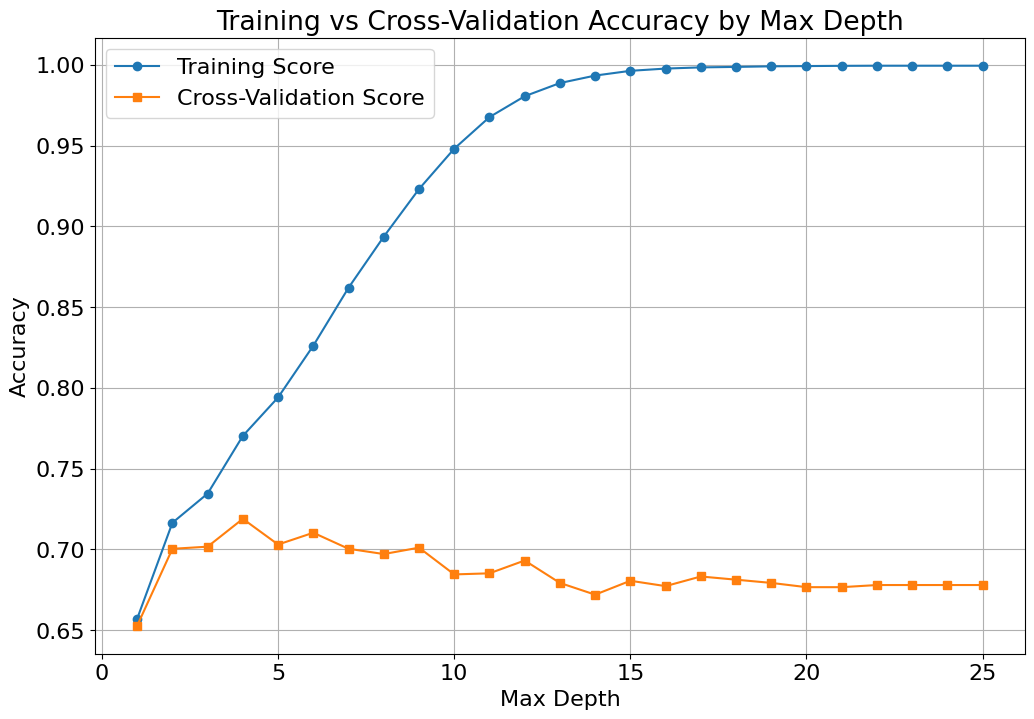

Optimal max_depth: 4
Best CV score: 0.7189


In [36]:
max_depths = range(1, 26)
train_scores = []
cv_scores = []

for depth in max_depths:
    clf_depth = DecisionTreeClassifier(max_depth=depth, random_state=123)
    
    cv_results = cross_validate(clf_depth, X_train, y_train, cv=10, return_train_score=True)
    train_scores.append(cv_results['train_score'].mean())
    cv_scores.append(cv_results['test_score'].mean())

plt.figure(figsize=(12, 8))
plt.plot(max_depths, train_scores, label='Training Score', marker='o')
plt.plot(max_depths, cv_scores, label='Cross-Validation Score', marker='s')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Cross-Validation Accuracy by Max Depth')
plt.legend()
plt.grid(True)
plt.show()

optimal_depth = max_depths[np.argmax(cv_scores)]
print(f"Optimal max_depth: {optimal_depth}")
print(f"Best CV score: {max(cv_scores):.4f}")

Type your answer here:

As max_depth increases training accuracy steadily increases. Cross-validation accuracy initially improves then gradually decreases due to overfitting. The optimal depth appears to be 4 where CV score is highest. This depth likely won't generalize well to other Spotify datasets because music preferences are highly individual.


## Exercise 4: Test set
rubric={points:12}

Remember the test set you created way back at the beginning of this assignment? Let's use it now to see if our cross-validation score from the previous exercise is trustworthy. 

- Select your favorite `max_depth` from the previous part.
- Train a decision tree classifier using that `max_depth` on the _entire training set_.
- Compute and display the test score. 
- How does it compare to the cross-validation score from the previous exercise? Briefly discuss. 

In [37]:
best_depth = 4
final_clf = DecisionTreeClassifier(max_depth=best_depth, random_state=123)
final_clf.fit(X_train, y_train)

test_score = final_clf.score(X_test, y_test)
print(f"Test score with max_depth={best_depth}: {test_score:.4f}")
print(f"Cross-validation score was: 0.7189")

Test score with max_depth=4: 0.7030
Cross-validation score was: 0.7189


Type the answer of forth question here:



## Exercise 5: Conceptual questions
rubric={points:8}

Consider the dataset below, which has $6$ examples and $2$ features:

$$ X = \begin{bmatrix}5 & 2\\4 & 3\\  2 & 2\\ 10 & 10\\ 9 & -1\\ 9& 9\end{bmatrix}, \quad y = \begin{bmatrix}-1\\-1\\+1\\+1\\+1\\+1\end{bmatrix}.$$

1. Say we fit a decision stump (depth 1 decision tree) and the first split is on the first feature (left column) being less than 5.5. What would we predict in the "true" and "false" cases here?
2. What training accuracy would the above stump get on this data set?
3. Can we obtain 100% accuracy with a single decision stump in this particular example?

Type your answer here:

1. True case (< 5.5): We have 2 examples with class -1 and 1 with class +1, so we'd predict -1. False case (≥ 5.5): All 3 examples have class +1, so we'd predict +1.

2. This stump would get 5/6 accuracy --> it would misclassify only the [2,2] 

3. No we cannot obtain 100% accuracy with a single decision stump because the [2,2] example with class

## Submission instructions 

**PLEASE READ:** When you are ready to submit your assignment do the following:

1. Run all cells in your notebook to make sure there are no errors by doing `Kernel -> Restart Kernel and Clear All Outputs` and then `Run -> Run All Cells`.
2. Notebooks with cell execution numbers out of order will have marks deducted. Notebooks without the output displayed may not be graded at all (because we need to see the output in order to grade your work).
3. Please keep your notebook clean and delete any throwaway code.